In [13]:
import importlib
import aaro_draft
import Conor
from IPython.display import Image, display
import aaro_experiments

importlib.reload(aaro_draft)
importlib.reload(Conor)
importlib.reload(aaro_experiments)

<module 'aaro_experiments' from '/workspaces/Research-Skills-for-Financial-Mathematics/aaro_experiments.py'>

In [14]:
import aaro_draft as ad
import Conor as c
import aaro_experiments as ae


In [32]:
cfg = ad.ExpConfig(
    alpha=0.5,
    label="alpha=0.5"
)
results = ad.run_experiment([cfg], n_jobs=-1)



--- Running: alpha=0.5 ---
    Done. Final mean VPI: -37.435


In [33]:
results["alpha=0.5"][:10]

array([-154.08755912, -225.46534033, -154.37506579, -134.3632921 ,
       -143.67085166, -153.0676052 ,  -85.34538083,  -87.44885083,
       -108.87528292,  -79.87437605])

In [34]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    ad.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = ad.run_experiment(configs, n_jobs=-1)
print(results.keys())


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -38.844

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -36.098

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -40.741

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -38.819

--- Running: alpha=1 ---
    Done. Final mean VPI: -38.475

--- Running: alpha=5 ---
    Done. Final mean VPI: -32.125

--- Running: alpha=10 ---
    Done. Final mean VPI: -33.262

--- Running: alpha=50 ---
    Done. Final mean VPI: -33.556

--- Running: alpha=100 ---


OverflowError: int too large to convert to float

### Why very large values of $\alpha$ (e.g., 100 or 500) do not work well

In the algorithm, the exploration bonus in the UCB update is

$$
\text{UCB} = \frac{\text{scaling}}{n^\alpha} + \text{scaling}\cdot \text{radius},
$$

where $n$ is the number of visits to the active node.

When $\alpha$ is extremely large (e.g., 100 or 500), the term $n^{-\alpha}$ decays **extremely quickly**.

For example:

- $1 / 2^{100} \approx 7.9 \times 10^{-31}$
- $1 / 3^{100} \approx 5.2 \times 10^{-48}$

After only one or two visits, the exploration bonus from the $n^{-\alpha}$ term becomes essentially **zero**.

As a result:

- The algorithm stops encouraging exploration very early.
- The Q-value updates become almost purely greedy.
- The agent may commit prematurely to suboptimal regions of the state–action space.
- The adaptive partitioning receives poor information, which can degrade learning performance.

Although the radius term still provides some spatial optimism, the rapid collapse of $n^{-\alpha}$ makes the algorithm behave much less like a UCB-style method.

For this reason, extremely large values such as $\alpha = 100$ or $\alpha = 500$ are not very informative in practice. More meaningful comparisons usually occur for values such as

$$
\alpha \in [0.01, 1],
$$

where the exploration bonus decays at a reasonable rate.


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -37.712

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -36.757

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -40.778

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -37.945

--- Running: alpha=1 ---
    Done. Final mean VPI: -37.514

--- Running: alpha=5 ---
    Done. Final mean VPI: -33.617

--- Running: alpha=10 ---
    Done. Final mean VPI: -32.416

--- Running: alpha=50 ---
    Done. Final mean VPI: -33.374


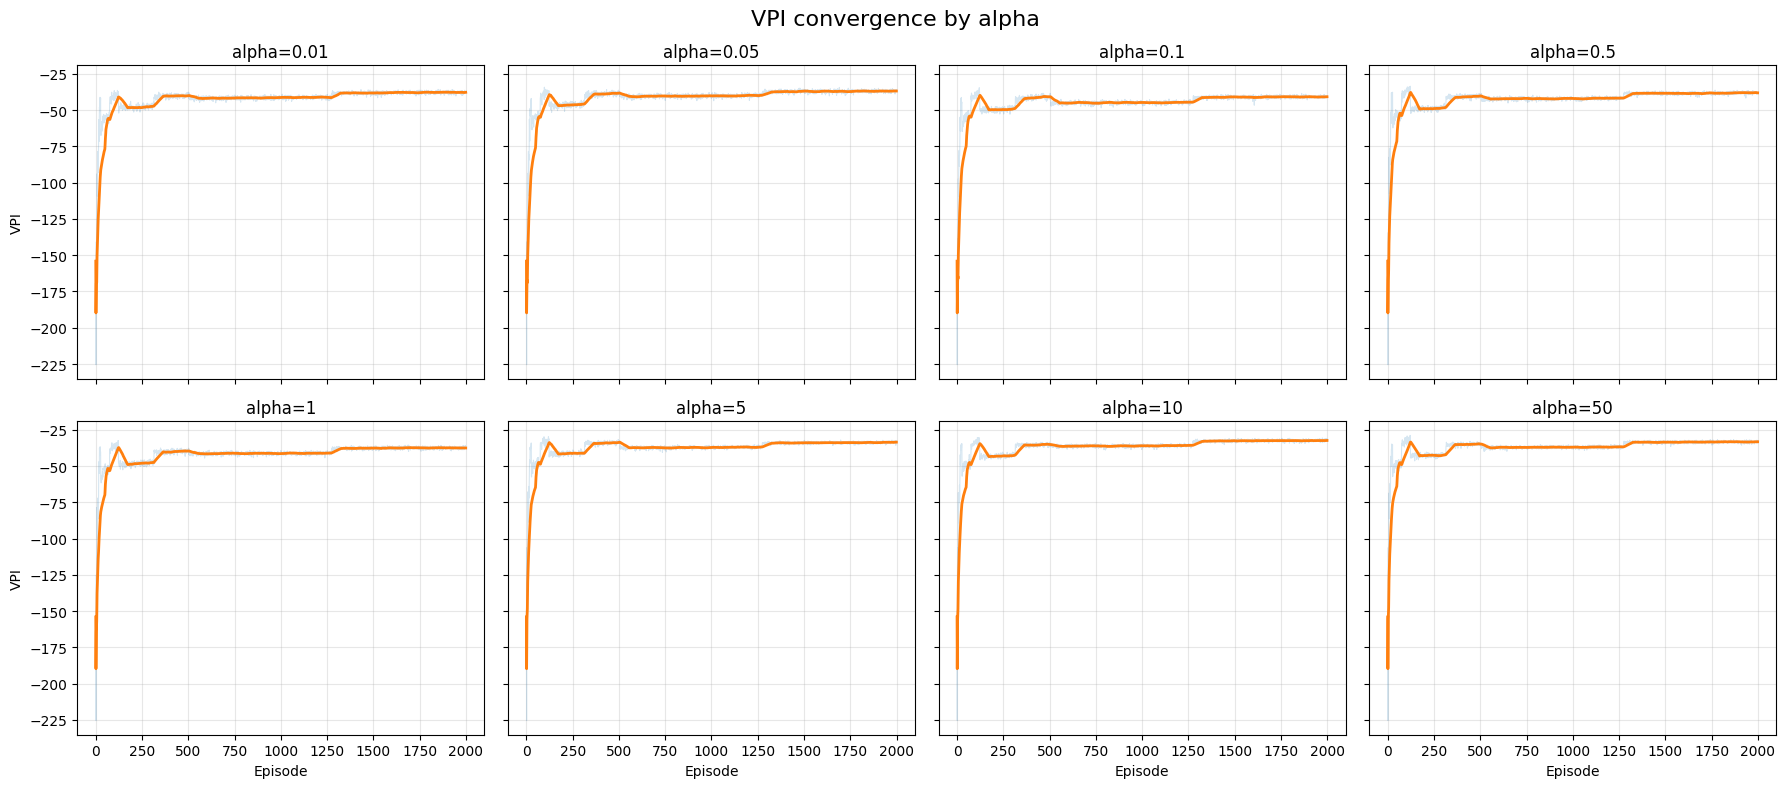

In [35]:
import numpy as np
import matplotlib.pyplot as plt
#alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]


alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    ad.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = ad.run_experiment(configs, n_jobs=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()

smooth_window = 50

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    vpi = results[label]
    episodes = np.arange(len(vpi))

    cumsum = np.cumsum(np.insert(vpi, 0, 0.0))
    smoothed = np.empty_like(vpi)
    for i in range(len(vpi)):
        start = max(0, i - smooth_window + 1)
        smoothed[i] = (cumsum[i + 1] - cumsum[start]) / (i - start + 1)

    ax.plot(episodes, vpi, alpha=0.18, linewidth=0.8)
    ax.plot(episodes, smoothed, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("VPI")

fig.suptitle("VPI convergence by alpha", fontsize=16)
fig.tight_layout()
plt.show()

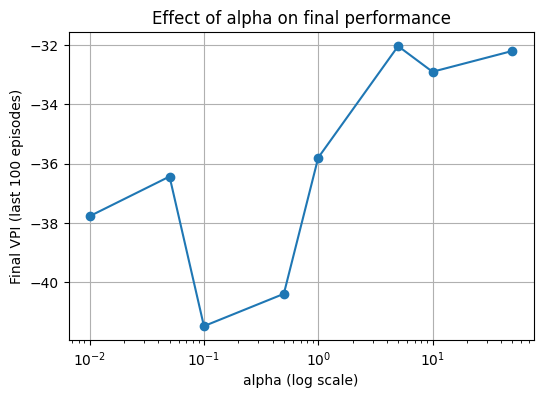

In [ ]:


final_vpi = []

for a in alphas:
    label = f"alpha={a}"
    v = results[label]
    final_vpi.append(np.mean(v[-100:]))

plt.figure(figsize=(6,4))
plt.plot(alphas, final_vpi, marker='o')
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Effect of alpha on final performance")
plt.grid(True)
plt.show()


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -37.874

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -35.741

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -41.208

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -38.473

--- Running: alpha=1 ---
    Done. Final mean VPI: -39.073

--- Running: alpha=5 ---
    Done. Final mean VPI: -33.272

--- Running: alpha=10 ---
    Done. Final mean VPI: -34.549

--- Running: alpha=50 ---
    Done. Final mean VPI: -31.997


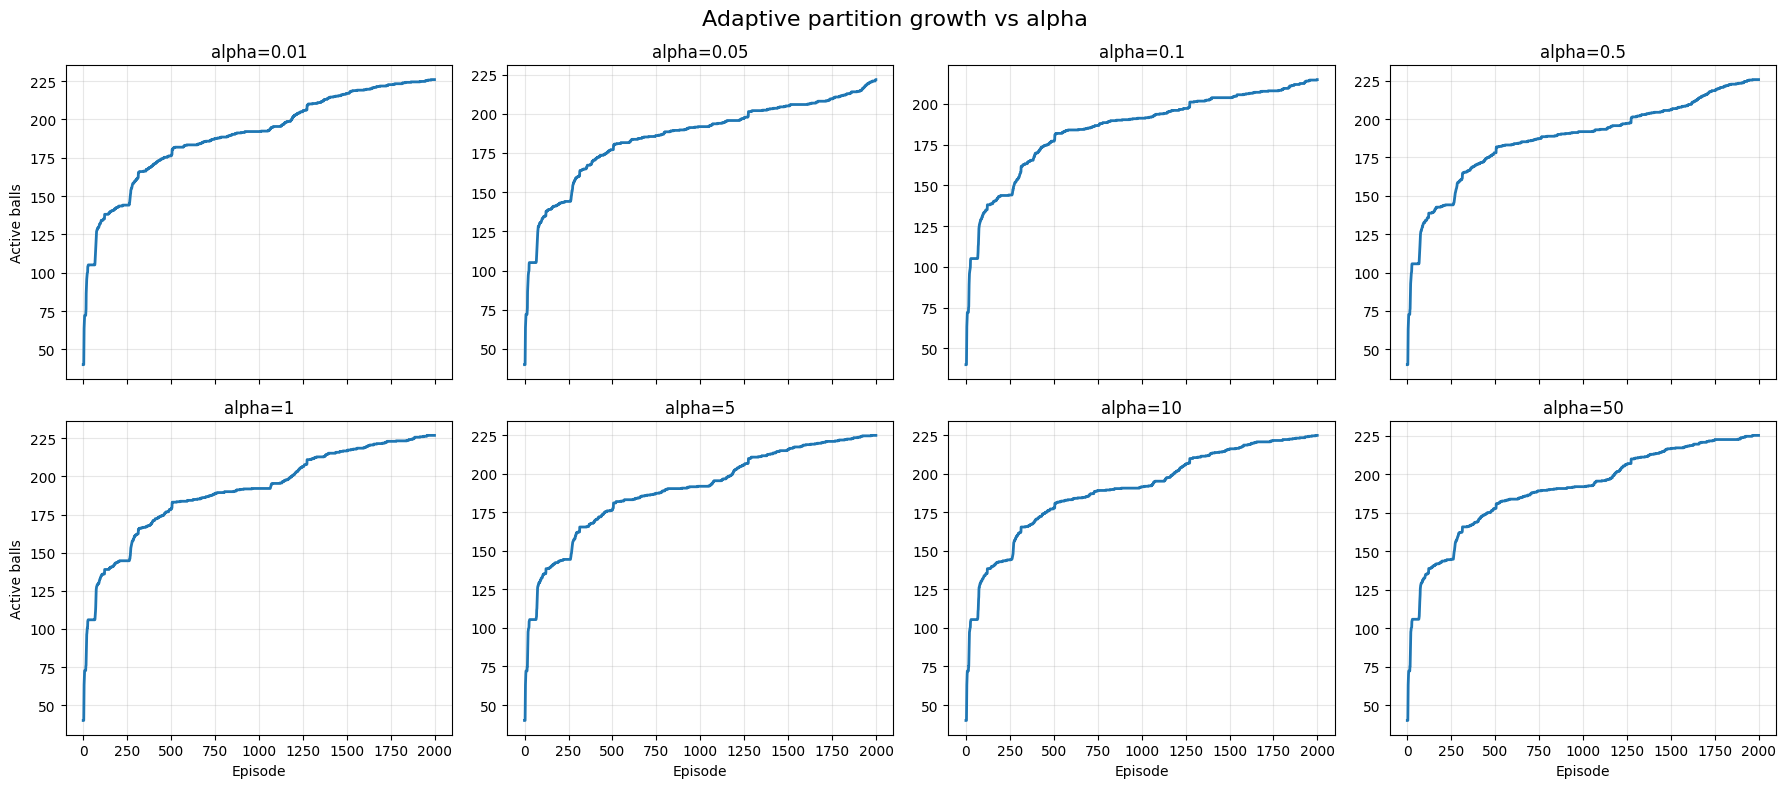

In [43]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)


fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.ravel()

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = results[label]["arms"]

    ax.plot(arms, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("Active balls")

fig.suptitle("Adaptive partition growth vs alpha", fontsize=16)
fig.tight_layout()
plt.show()

The above plot explains how quick the partition grows. We seee rapid growth early on and then a plateua arond 200 ish. Overall the algorithim doesnt seem to be vey sensitive to alpha as there is little difference between alpha = 0.1 and alpha = 50

In [4]:
## Checking difference between bellman updates vs one step updates on regret



# Run the comparative study
comparative_results = ad.run_comparative_study(n_jobs=-1)

# Optionally plot and print summary
ad.plot_comparative_study(comparative_results, save_path='comparative_study.png')
ad.print_comparative_summary(comparative_results)


--- Running Comparative Study: Full Bellman Update ---
    use_bellman=True, inherit_flag=False
    Done. Final mean VPI: -29.751 ± 5.201
    Total time: 4.33s, Mean per seed: 0.85s

--- Running Comparative Study: One-Step Update ---
    use_bellman=False, inherit_flag=False
    Done. Final mean VPI: -0.646 ± 0.492
    Total time: 3.89s, Mean per seed: 0.77s
Comparative study plot saved to comparative_study.png

COMPARATIVE STUDY SUMMARY: Full Bellman vs One-Step Update

Metric                         Full Bellman    One-Step        Difference     
----------------------------------------------------------------------
Final VPI (last 100 eps)       -29.751         -0.646          -29.105
Final Active Balls             204             204             +1
Mean Time per Seed (s)         0.85            0.77            1.11x
Episodes to 90% Final VPI      2000            566             +1434

Interpretation:
- Full Bellman: Uses complete value function propagation (higher precision)
- One

In [15]:
# bellman tuning

# Does tuning help Bellman?
tuning_results = ae.run_bellman_tuning_study()

# Bellman wins with delayed rewards
delayed_results = ae.run_delayed_reward_experiment()
ae.plot_delayed_reward_comparison(delayed_results)

challenging_results = ae.run_challenging_delayed_reward(n_jobs=-1)
ae.plot_challenging_delayed_reward(challenging_results)
ae.print_challenging_summary(challenging_results)


--- Tuning Study: One-Step (Baseline) ---
    Final VPI: -0.646 ± 0.482, Time: 4.24s

--- Tuning Study: Bellman (Original) ---
    Final VPI: -31.359 ± 8.469, Time: 4.29s

--- Tuning Study: Bellman (init_q=10) ---
    Final VPI: -20.482 ± 6.368, Time: 4.36s

--- Tuning Study: Bellman (lip=0) ---
    Final VPI: -32.235 ± 8.347, Time: 4.59s

--- Tuning Study: Bellman (q=10, lip=0) ---
    Final VPI: -19.952 ± 8.115, Time: 4.48s

--- Delayed Reward Experiment: Bellman (Delayed Reward) ---
    Goal: 0.0, Start: 4.0, Reward type: terminal
    Final VPI: -5.390 ± 0.954
    Time: 6.17s

--- Delayed Reward Experiment: One-Step (Delayed Reward) ---
    Goal: 0.0, Start: 4.0, Reward type: terminal
    Final VPI: -5.468 ± 0.956
    Time: 6.52s
Delayed reward plot saved to delayed_reward_comparison.png

--- Challenging Delayed Reward: Bellman (Challenging) ---
    Goal: 5.0, Start: 0.0
    theta_x: 0.1 (unstable), theta_a: 0.5 (strong action effect)
    Final VPI: -1852.585 ± 235.617
    Time: 4.